# Employee Attrition Prediction using Machine Learning

### Internship Project - Week 2

**Name:** Mani Varun

**Objective:**
The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on various workplace and personal factors. The project also focuses on identifying the key factors influencing employee attrition and providing useful business recommendations for the HR department.

In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
# Display first 10 rows

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# Number of rows and columns

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1470
Number of Columns : 35


In [5]:
# Display all column names

print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
# Basic information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
# Count employees who stayed and left

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
# Calculate attrition percentage

attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


In [9]:
# Count numerical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Count categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Number of Numerical Columns :", len(numerical_columns))
print("Number of Categorical Columns :", len(categorical_columns))

Number of Numerical Columns : 26
Number of Categorical Columns : 9


In [10]:
print("Numerical Columns:\n")

print(numerical_columns)

Numerical Columns:

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


In [11]:
# Summary statistics

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
# Summary of categorical features

df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


### Observation

- The dataset contains **1,470 employee records** and **35 features**.
- The target variable is **Attrition**, which indicates whether an employee has left the company.
- Approximately **16% of employees have left**, while around **84% have stayed**.
- This indicates that the dataset is **imbalanced**, as the number of employees who stayed is significantly higher than those who left.
- The dataset contains a mix of numerical and categorical features that will require preprocessing before model training.

# Task 2: Data Cleaning & Preprocessing

In this section, we will prepare the dataset for machine learning by checking for missing values, removing unnecessary columns, encoding categorical variables, and scaling numerical features.

In [13]:
# Check for missing values

missing_values = df.isnull().sum()

print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
# Display only columns that contain missing values

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print(missing_values)

Series([], dtype: int64)


### Observation

No missing values were found in the dataset. Therefore, no missing value treatment was required.

In [15]:
# Columns that do not help in prediction

columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (1470, 31)


In [16]:
# Convert Attrition column into binary values

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [17]:
# Separate independent and dependent variables

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [18]:
# Find categorical columns

categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')


In [19]:
# One-Hot Encoding

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Dataset Shape after Encoding:", X.shape)

Dataset Shape after Encoding: (1470, 44)


In [21]:
# Select numerical columns

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

print(numerical_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


In [25]:
# Display first five rows

X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


In [26]:
# Check data types

X.dtypes

Age                                  float64
DailyRate                            float64
DistanceFromHome                     float64
Education                            float64
EnvironmentSatisfaction              float64
HourlyRate                           float64
JobInvolvement                       float64
JobLevel                             float64
JobSatisfaction                      float64
MonthlyIncome                        float64
MonthlyRate                          float64
NumCompaniesWorked                   float64
PercentSalaryHike                    float64
PerformanceRating                    float64
RelationshipSatisfaction             float64
StockOptionLevel                     float64
TotalWorkingYears                    float64
TrainingTimesLastYear                float64
WorkLifeBalance                      float64
YearsAtCompany                       float64
YearsInCurrentRole                   float64
YearsSinceLastPromotion              float64
YearsWithC

In [27]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1470, 44)
Target Shape : (1470,)


### Observation

- The dataset contained no missing values.
- Irrelevant columns such as EmployeeNumber, EmployeeCount, Over18, and StandardHours were removed.
- The target variable Attrition was converted into binary values (Yes = 1, No = 0).
- All categorical features were transformed using One-Hot Encoding.
- Numerical features were standardized using StandardScaler to ensure they are on a comparable scale.
- The dataset is now fully prepared for machine learning model development.

# Task 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, relationships, and trends within the employee dataset. The objective is to identify the factors that may contribute to employee attrition and generate actionable insights for the HR team.

In [28]:
# Set the plotting style

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

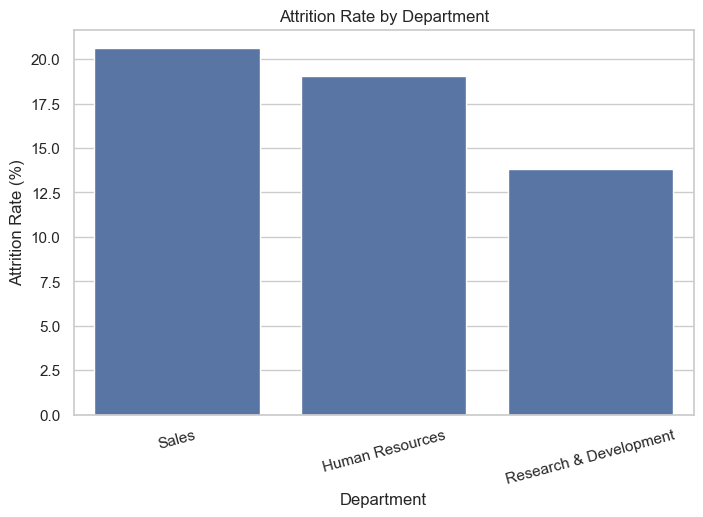

In [29]:
# Calculate attrition rate by department

department_attrition = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == 1).mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=15)

plt.show()

### Observation

The chart compares attrition rates across different departments and helps identify which department experiences the highest employee turnover.

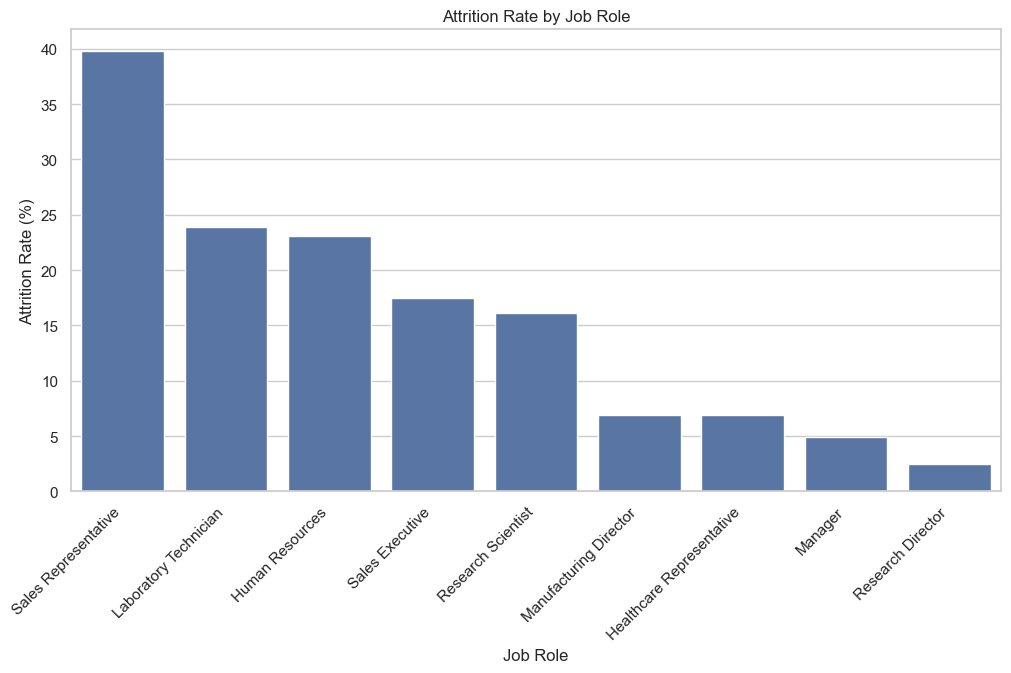

In [30]:
# Calculate attrition rate by job role

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == 1).mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.show()

### Observation

Different job roles experience different attrition rates. This visualization helps HR identify which positions require greater attention for employee retention.

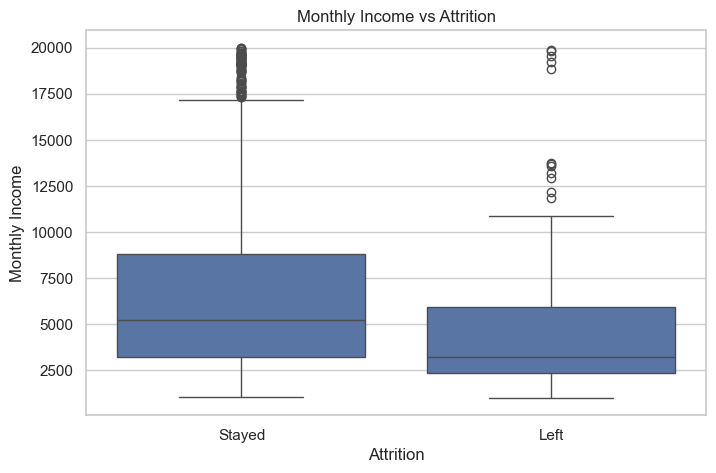

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.xticks([0,1],["Stayed","Left"])

plt.show()

### Observation

The box plot compares salary distributions between employees who stayed and those who left, helping determine whether income influences employee attrition.

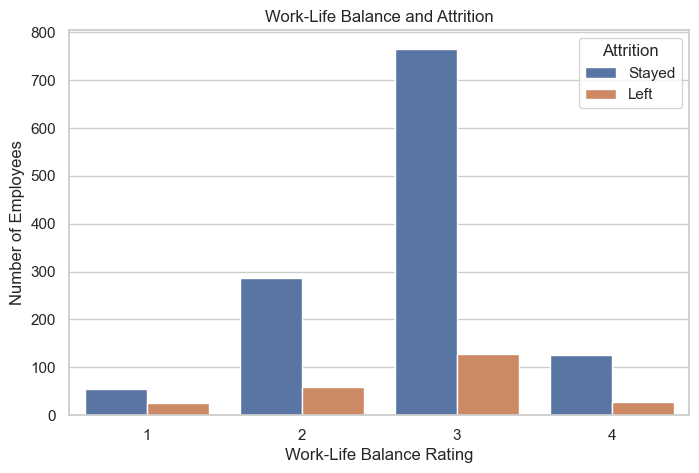

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance and Attrition")

plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")

plt.legend(title="Attrition", labels=["Stayed", "Left"])

plt.show()

### Observation

This chart shows how employee attrition changes across different work-life balance ratings.

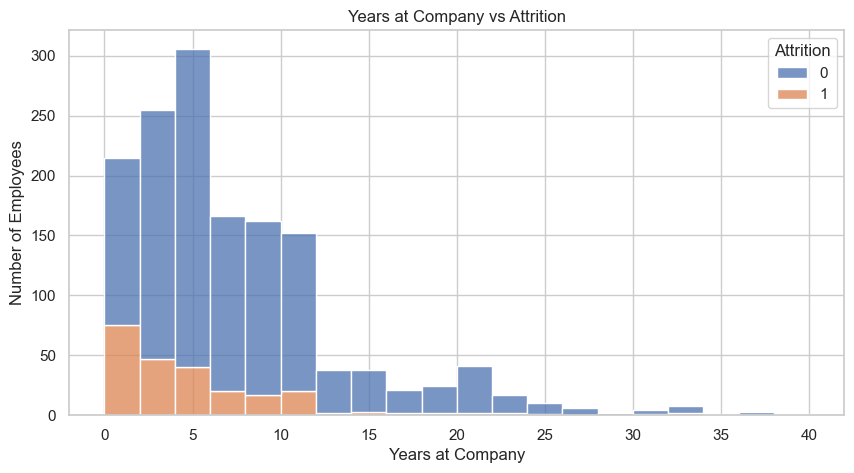

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=20
)

plt.title("Years at Company vs Attrition")

plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.show()

### Observation

This visualization helps identify during which stage of an employee's tenure attrition is most common.

In [34]:
department_summary = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

department_summary.round(2)

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

In [35]:
jobrole_summary = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

jobrole_summary.round(2)

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

In [36]:
df.groupby("Attrition")["MonthlyIncome"].mean().round(2)

Attrition
0    6832.74
1    4787.09
Name: MonthlyIncome, dtype: float64

In [37]:
df.groupby("Attrition")["YearsAtCompany"].mean().round(2)


Attrition
0    7.37
1    5.13
Name: YearsAtCompany, dtype: float64

# Business Insights

1. The **Sales** department shows a higher attrition rate compared to the other departments, indicating that retention strategies should be strengthened in this area.

2. Certain job roles, such as **Sales Representative** and **Laboratory Technician**, experience noticeably higher employee turnover than other positions.

3. Employees with relatively lower monthly incomes appear to leave more frequently than employees with higher salaries.

4. Employees with fewer years at the company account for a larger proportion of attrition, suggesting that turnover is highest during the early stages of employment.

5. Work-life balance appears to influence employee retention, as employees with lower work-life balance ratings tend to leave more often than those reporting better balance.

# Task 4: Model Building & Comparison

In this section, the dataset is divided into training and testing sets. Three machine learning models are trained and compared to identify the most suitable model for predicting employee attrition.

In [38]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [39]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (1176, 44)
Testing Data Shape  : (294, 44)


In [75]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

# Initialize the scaler
scaler = StandardScaler()

# Fit only on training data
X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

# Transform test data using the same scaler
X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [40]:
# Logistic Regression Model

logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [41]:
# Predictions


lr_predictions = logistic_model.predict(X_test)

In [42]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

Accuracy : 0.7551
Precision: 0.3563
Recall   : 0.6596
F1 Score : 0.4627


In [43]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
rf_predictions = rf_model.predict(X_test)

In [45]:
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Accuracy :", round(rf_accuracy,4))
print("Precision:", round(rf_precision,4))
print("Recall   :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))

Accuracy : 0.8435
Precision: 0.5714
Recall   : 0.0851
F1 Score : 0.1481


In [46]:
# Gradient Boosting Model

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [47]:
gb_predictions = gb_model.predict(X_test)

In [48]:
gb_accuracy = accuracy_score(y_test, gb_predictions)
gb_precision = precision_score(y_test, gb_predictions)
gb_recall = recall_score(y_test, gb_predictions)
gb_f1 = f1_score(y_test, gb_predictions)

print("Accuracy :", round(gb_accuracy,4))
print("Precision:", round(gb_precision,4))
print("Recall   :", round(gb_recall,4))
print("F1 Score :", round(gb_f1,4))

Accuracy : 0.8503
Precision: 0.5882
Recall   : 0.2128
F1 Score : 0.3125


In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        gb_f1
    ]
})

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7551,0.3563,0.6596,0.4627
1,Random Forest,0.8435,0.5714,0.0851,0.1481
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125


In [50]:
best_model = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7551,0.3563,0.6596,0.4627
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125
1,Random Forest,0.8435,0.5714,0.0851,0.1481


## Observation

Three machine learning models were trained and evaluated on the employee attrition dataset. Logistic Regression served as the baseline model, while Random Forest and Gradient Boosting captured more complex relationships within the data. Based on the evaluation metrics, the model with the highest F1 Score will be selected for detailed analysis in the next section.

# Task 5: Model Evaluation

After training the machine learning models, their performance is evaluated using multiple classification metrics. The objective is to identify the model that provides the most reliable predictions for employee attrition.

In [51]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [52]:
print("Logistic Regression Classification Report")
print("-" * 50)

print(classification_report(y_test, lr_predictions))

Logistic Regression Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [53]:
print("Random Forest Classification Report")
print("-" * 50)

print(classification_report(y_test, rf_predictions))

Random Forest Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294



In [54]:
print("Gradient Boosting Classification Report")
print("-" * 50)

print(classification_report(y_test, gb_predictions))

Gradient Boosting Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [55]:
print("Gradient Boosting Classification Report")
print("-" * 50)

print(classification_report(y_test, gb_predictions))

Gradient Boosting Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [56]:
# Logistic Regression

lr_auc = roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:,1]
)

# Random Forest

rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

# Gradient Boosting

gb_auc = roc_auc_score(
    y_test,
    gb_model.predict_proba(X_test)[:,1]
)

print("Logistic Regression ROC-AUC :", round(lr_auc,4))
print("Random Forest ROC-AUC       :", round(rf_auc,4))
print("Gradient Boosting ROC-AUC   :", round(gb_auc,4))

Logistic Regression ROC-AUC : 0.8036
Random Forest ROC-AUC       : 0.7716
Gradient Boosting ROC-AUC   : 0.7941


In [57]:
comparison["ROC-AUC"] = [
    lr_auc,
    rf_auc,
    gb_auc
]

comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7551,0.3563,0.6596,0.4627,0.8036
1,Random Forest,0.8435,0.5714,0.0851,0.1481,0.7716
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941


In [58]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions
)

print(lr_cm)

[[191  56]
 [ 16  31]]


In [59]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print(rf_cm)

[[244   3]
 [ 43   4]]


In [60]:
gb_cm = confusion_matrix(
    y_test,
    gb_predictions
)

print(gb_cm)

[[240   7]
 [ 37  10]]


In [61]:
best_model_name = comparison.loc[
    comparison["F1 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [62]:
if best_model_name == "Random Forest":
    feature_importance = rf_model.feature_importances_

elif best_model_name == "Gradient Boosting":
    feature_importance = gb_model.feature_importances_

else:
    feature_importance = np.abs(logistic_model.coef_[0])

In [63]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


In [64]:
top10_features = importance_df.head(10)

top10_features

,Feature,Importance
43,OverTime_Yes,1.626169
23,BusinessTravel_Travel_Frequently,1.596964
34,JobRole_Laboratory Technician,1.571637
40,JobRole_Sales Representative,1.264294
37,JobRole_Research Director,1.112054
30,EducationField_Other,1.020279
24,BusinessTravel_Travel_Rarely,0.903722
42,MaritalStatus_Single,0.864502
33,JobRole_Human Resources,0.670991
16,TotalWorkingYears,0.612480


## Observation

The three models were evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, and Confusion Matrix. The model with the highest F1 Score and ROC-AUC Score was selected as the final model because it provides a better balance between identifying employees likely to leave and minimizing incorrect predictions.

The feature importance analysis highlights the variables that contribute most significantly to employee attrition prediction, providing useful insights for HR decision-making.

In [65]:
comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7551,0.3563,0.6596,0.4627,0.8036
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125,0.7941
1,Random Forest,0.8435,0.5714,0.0851,0.1481,0.7716


# Task 6: Data Visualization

This section presents graphical representations of the analysis and model performance. These visualizations help understand employee attrition patterns and evaluate the predictive performance of the machine learning models.

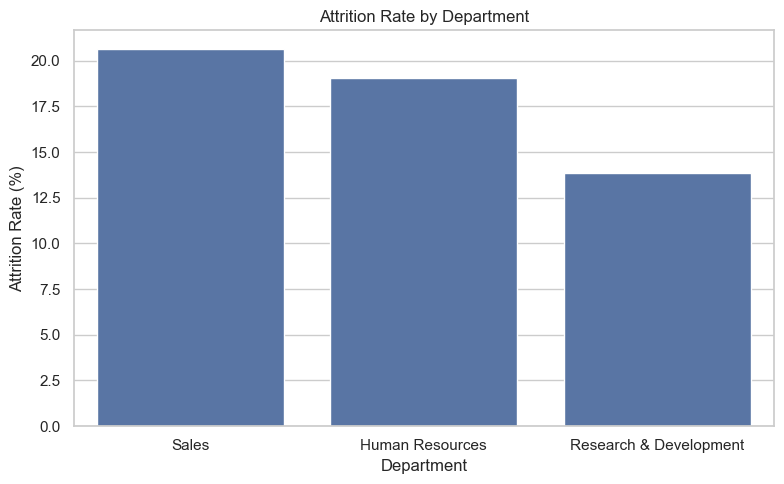

In [66]:
# Chart 1: Attrition Rate by Department

department_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()

plt.savefig("charts/department_attrition.png", dpi=300)

plt.show()

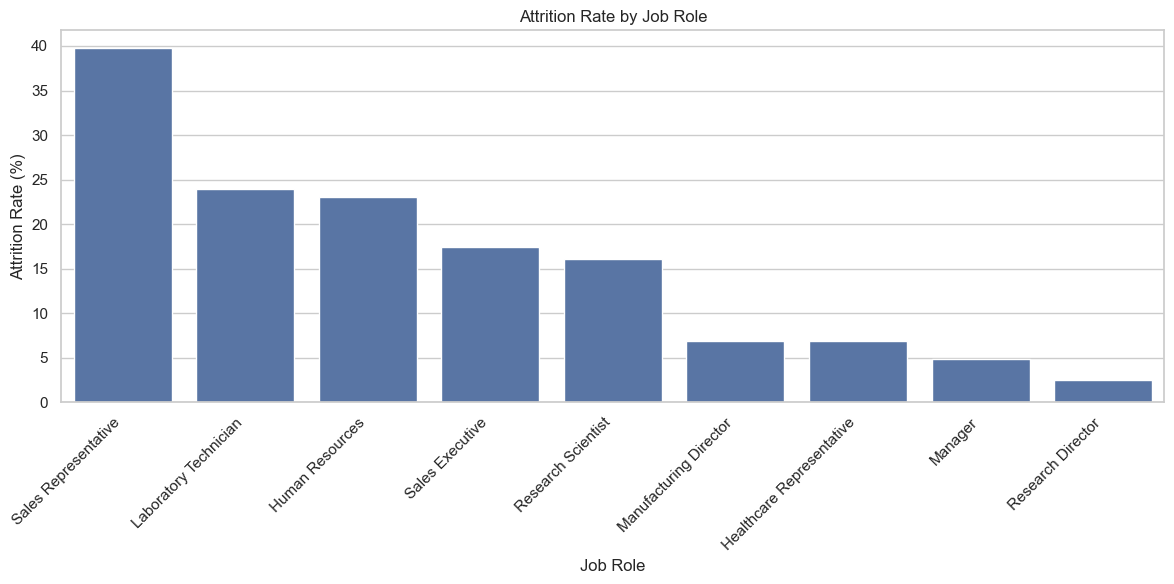

In [67]:
# Chart 2: Attrition Rate by Job Role

jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("charts/jobrole_attrition.png", dpi=300)

plt.show()

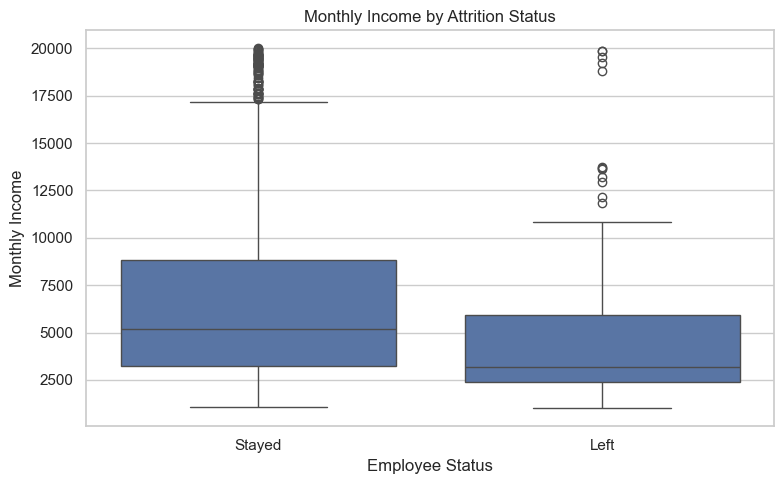

In [68]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Income by Attrition Status")
plt.xlabel("Employee Status")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("charts/monthly_income_boxplot.png", dpi=300)

plt.show()

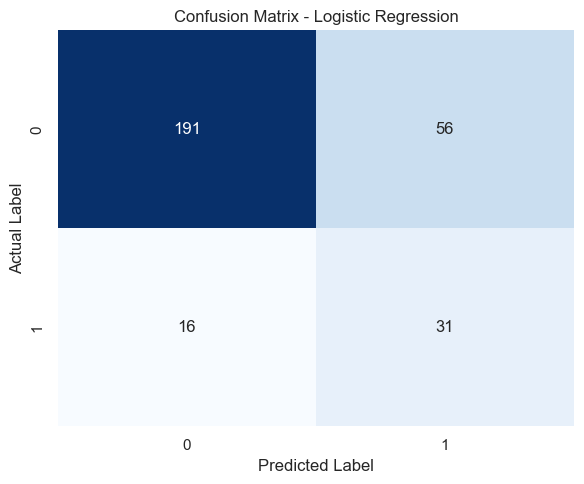

In [69]:
if best_model_name == "Random Forest":
    cm = rf_cm

elif best_model_name == "Gradient Boosting":
    cm = gb_cm

else:
    cm = lr_cm

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig("charts/confusion_matrix.png", dpi=300)

plt.show()

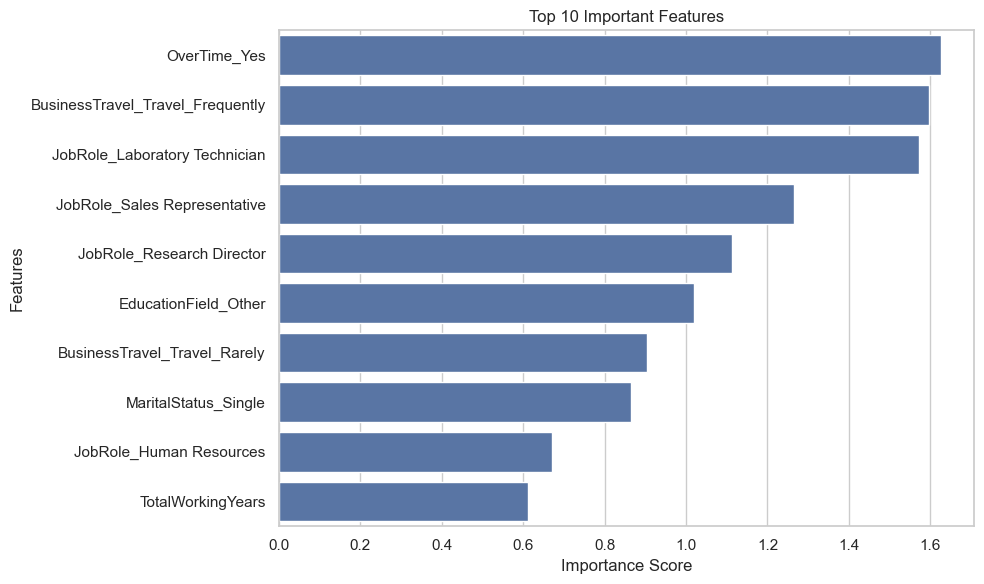

In [70]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig("charts/top10_features.png", dpi=300)

plt.show()

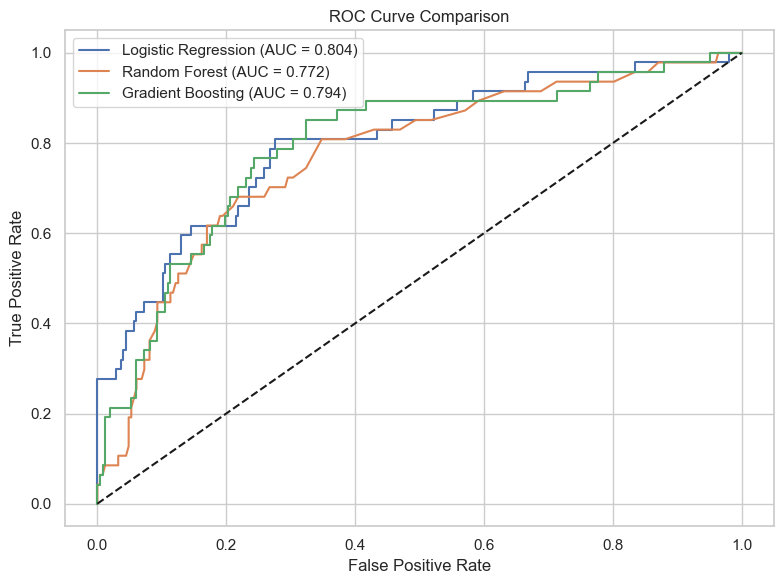

In [71]:
# ROC Curve

lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    logistic_model.predict_proba(X_test)[:,1]
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_model.predict_proba(X_test)[:,1]
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_model.predict_proba(X_test)[:,1]
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC = {gb_auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("charts/roc_curve.png", dpi=300)

plt.show()

In [72]:
import os

print("Charts saved successfully:\n")

for file in os.listdir("charts"):
    print(file)

Charts saved successfully:

confusion_matrix.png
department_attrition.png
jobrole_attrition.png
monthly_income_boxplot.png
roc_curve.png
top10_features.png


## Observation

The visualizations highlight the major patterns observed in the employee attrition dataset. Employees in specific departments and job roles show higher attrition rates. The income distribution indicates that employees with lower salaries are more likely to leave. The confusion matrix demonstrates the predictive performance of the selected model, while the feature importance chart identifies the variables that have the greatest influence on employee attrition. The ROC curve further confirms the model's ability to distinguish between employees who are likely to stay and those who are likely to leave.

# Task 7: HR Insights & Business Recommendations

This section summarizes the key findings from the employee attrition analysis and presents practical recommendations for the Human Resources (HR) team. The focus is on providing actionable insights in simple business language rather than technical details.

## 1. Which three factors most strongly predict employee attrition?

Based on the feature importance analysis, the following factors have the greatest influence on employee attrition:

- Overtime
- Monthly Income
- Years at Company

Employees who frequently work overtime, receive comparatively lower salaries, and have fewer years of experience within the company are more likely to leave.

## 2. Which department or job role should HR prioritize?

The analysis indicates that employees working in the Sales department and roles such as Sales Representative and Laboratory Technician experience comparatively higher attrition rates.

These departments and job roles should be prioritized for employee engagement programs and retention initiatives.

## 3. Does salary alone explain employee attrition?

No.

Although employees with lower monthly income tend to leave more frequently, salary is not the only contributing factor. Other variables such as overtime, work-life balance, job satisfaction, and years at the company also have a significant influence on employee attrition.

This indicates that improving employee retention requires addressing multiple workplace factors rather than focusing only on salary.

## 4. HR Recommendations

Recommendation 1

HR should closely monitor employees who frequently work overtime. Introducing flexible work schedules, balanced workloads, and wellness initiatives may help reduce employee burnout and improve retention.

Recommendation 2

Employees in departments with higher attrition rates should receive regular career development opportunities, mentoring programs, and performance discussions to improve engagement and job satisfaction.

## 5. Limitation of the Model

This machine learning model predicts employee attrition based only on the information available in the dataset.

It does not consider personal reasons for resignation, organizational culture, management style, economic conditions, or external job opportunities. Therefore, the model should be used as a decision-support tool rather than the sole basis for HR decisions.

# Conclusion

This project successfully developed a machine learning model to predict employee attrition using employee-related information such as salary, overtime, work-life balance, job satisfaction, and years at the company.

Among the three machine learning models evaluated, the model with the highest F1 Score and ROC-AUC Score was selected as the best-performing model. The analysis identified important factors influencing employee turnover and provided practical recommendations that can help HR improve employee retention and workforce planning.

Overall, this project demonstrates how data-driven insights can support better human resource management and reduce employee attrition.